# 正式训练阶段

本 Notebook 只是做调试探索代码使用，实现代码见 `py` 文件


## 读取数据集
由于原论文作者一直没有授权给我使用数据集，这里我从油管上爬了 6 个会议视频根据 VISTA 数据集做了一个非常小的 `practice_data`

In [1]:
import torch
from datasets import load_dataset

data_root = "./data/practice_data"

dataset = load_dataset(
    "json",
    data_files=str(data_root + "/train_part1.json"),
    split="train",
)

print("字面数据集的字段：",dataset.column_names)

字面数据集的字段： ['id', 'title', 'authors', 'abstract', 'video_file', 'video_path', 'paper_url', 'venue']


In [2]:
dataset = dataset.select_columns(['abstract','video_path'])
dataset

Dataset({
    features: ['abstract', 'video_path'],
    num_rows: 6
})

In [4]:
dataset = load_dataset(
    "json",
    data_files=str(data_root + "/train_part1.json"),
    split="train",
)

## 根据原文摘要生成 Plan
由于我没有 GPT-o1 的 API，这里调用 Deepseek V4 Flash API，提示词采用原论文提示词

In [5]:
# %uv pip install openai

In [22]:
from openai import OpenAI
from getpass import getpass

client = OpenAI(
    api_key=getpass("输入 DeepSeek API Key："),
    base_url="https://api.deepseek.com",
)

teacher_model = "deepseek-flash"

In [23]:
reference_sentences  = dataset[0]['abstract']

# 为了不引入过多的依赖，这里采用轻量的 pysbd 进行分句
import pysbd
seg = pysbd.Segmenter(language='en',clean=False)

reference_sentences = seg.segment(reference_sentences)

reference_sentences

['Diffusion models indirectly estimate the probability density over a data space, which can be used to study its structure. ',
 'In this work, we show that geodesics can be computed in diffusion latent space, where the norm induced by the spatially-varying inner product is inversely proportional to the probability density. ',
 'In this formulation, a path that traverses a high density (that is, probable) region of image latent space is shorter than the equivalent path through a low density region. ',
 'We present algorithms for solving the associated initial and boundary value problems and show how to compute the probability density along the path and the geodesic distance between two points. ',
 'Using these techniques, we analyze how closely video clips approximate geodesics in a pre-trained image diffusion space. ',
 'Finally, we demonstrate how these techniques can be applied to training-free image sequence interpolation and extrapolation, given a pre-trained image diffusion model.

In [24]:
question_prompt = """Generate a coherent and contextually relevant question based on the provided context and target sentence, ensuring that the target sentence can be treated as an answer to the generated question.

Output only one question in plain text.
Do not include Markdown formatting, labels, numbering, quotation marks, explanations, or answers.

Context: {context}
Target: {target}
Question Sentence:"""

In [26]:
plan = []

question_records = []

for i,target in enumerate(reference_sentences):
    context = " ".join(reference_sentences[:i]) # 考虑前文
    prompt = question_prompt.format(
        context=context,
        target=target,
    )

    response = client.chat.completions.create(
        model=teacher_model,
        messages=[
            {"role": "user", "content": prompt},
        ],
        max_tokens=512,
    )
    choice = response.choices[0]

    question = (choice.message.content or "").strip()

    plan.append(question)

    # 保留对应关系，方便检查问题是否合适
    question_records.append({
        "sentence_id": i + 1,
        "context": context,
        "target": target,
        "question": question,
    })

    print(f"第 {i + 1} 句：{target}")
    print(f"对应问题：{question}\n")


第 1 句：Diffusion models indirectly estimate the probability density over a data space, which can be used to study its structure. 
对应问题：What do diffusion models indirectly estimate over a data space, and what can this estimate be used for?

第 2 句：In this work, we show that geodesics can be computed in diffusion latent space, where the norm induced by the spatially-varying inner product is inversely proportional to the probability density. 
对应问题：What do the authors show about computing geodesics in diffusion latent space in relation to probability density?

第 3 句：In this formulation, a path that traverses a high density (that is, probable) region of image latent space is shorter than the equivalent path through a low density region. 
对应问题：In this formulation, how does the length of a path through a high-density region of image latent space compare with that of an equivalent path through a low-density region?

第 4 句：We present algorithms for solving the associated initial and boundary valu

# Summarization Model

## Plan Generation (PG)

将视频输入给多模态模型

视频完整路径： data/practice_data/videos/train_part1/1-cvpr-2025.mp4


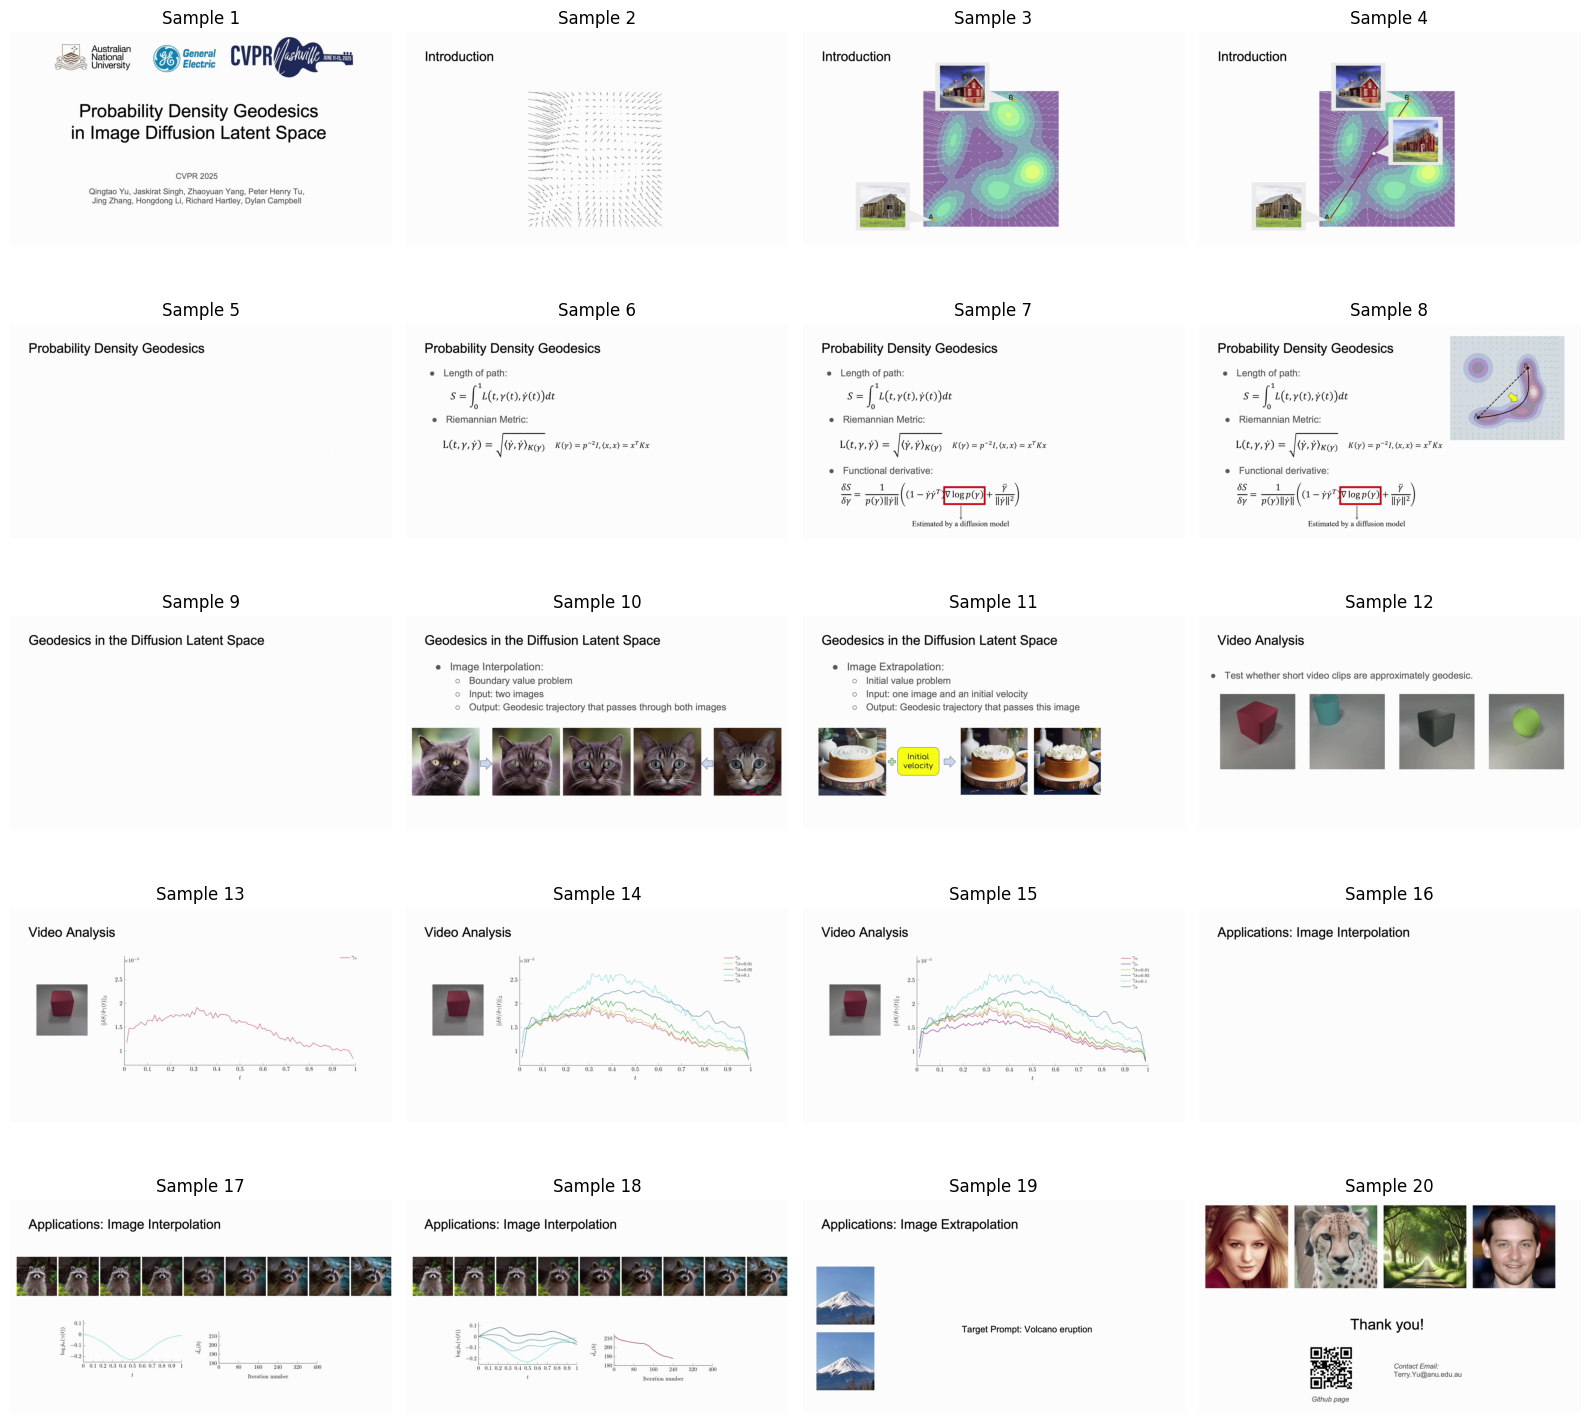

In [54]:
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def visualize_frames(frames):
    if not frames:
        raise ValueError("没有可显示的视频帧")

    num_rows = math.ceil(len(frames) / 4)

    fig, axes = plt.subplots(
        num_rows, 4,
        figsize=(16, 3 * num_rows),
        squeeze=False,
    )

    # 包括没有图片的空白格子，也关闭坐标轴
    for ax in axes.flat:
        ax.axis("off")

    for i, (frame, ax) in enumerate(zip(frames, axes.flat)):
        ax.imshow(frame)
        ax.set_title(f"Sample {i + 1}")

    plt.tight_layout()
    plt.show()


def process_video(video_path, num_frames):
    if num_frames <= 0:
        raise ValueError("num_frames 必须大于 0")

    cap = cv2.VideoCapture(str(video_path))

    frames = []

    try:
        if not cap.isOpened():
            raise RuntimeError(f"打开 {video_path} 时失败")

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames <= 0:
            raise RuntimeError(f"无法获取视频帧数：{video_path}")

        frame_indices = np.linspace(
            0,
            total_frames - 1,
            min(num_frames, total_frames),
            dtype=int,
        )

        for index in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(index))

            success, frame = cap.read()
            if not success:
                raise RuntimeError(
                    f"在视频 {video_path} 读取第 {index} 帧时失败"
                )

            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    finally:
        cap.release()

    return frames




data_root = Path("./data/practice_data")
num_frames = 20
sample = dataset[0]
video_path = data_root / Path(sample["video_path"])
print("视频完整路径：", video_path)

if not video_path.is_file():
    raise FileNotFoundError(f"视频文件不存在：{video_path}")

frames = process_video(video_path, num_frames)
visualize_frames(frames)

In [63]:
import torch

def to_Tensor(frames):
    """
    由于模型的 processor 会自动做归一化，resize，我们只需要将 frame 转为 tensor 即可
    """
    frames = np.array(frames)
    frames_tensor = torch.from_numpy(frames).float().permute(0,3,1,2) # 变为 (T,C,H,W)
    return frames_tensor
    return frames_tensor

tensor_frames = to_Tensor(frames)
print('转换之后的数据:',tensor_frames.shape)


batch_tensor = tensor_frames.unsqueeze(0)

batch_tensor.shape

转换之后的数据: torch.Size([20, 3, 720, 1280])


torch.Size([1, 20, 3, 720, 1280])

In [67]:
from transformers import AutoTokenizer,AutoModel


model_dir = '/Users/tuttokey/.cache/modelscope/models/iic--mPLUG-Owl3-2B-241014/snapshots/master'


tokenizer = AutoTokenizer.from_pretrained(
    model_dir,
    trust_remote_code=True,
    local_files_only=True,
)

model = AutoModel.from_pretrained(
    str(model_dir),
    trust_remote_code=True,
    local_files_only=True,
    attn_implementation="sdpa",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
)

device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.mps.is_available() else 'cpu')

/opt/anaconda3/envs/vista_env/lib/python3.10/site-packages/transformers/models/auto/image_processing_auto.py:517: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(
HyperQwen2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, 

import flash_attn rotary fail
